In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

In [4]:
USAGE_CSV = "gen8ou_usage.csv"
ITEMS_CSV = "gen8ou_items.csv"
TEAM_CSV = "gen8ou_teams.csv"
TEAMMATES_CSV = "gen8ou_teammates.csv"

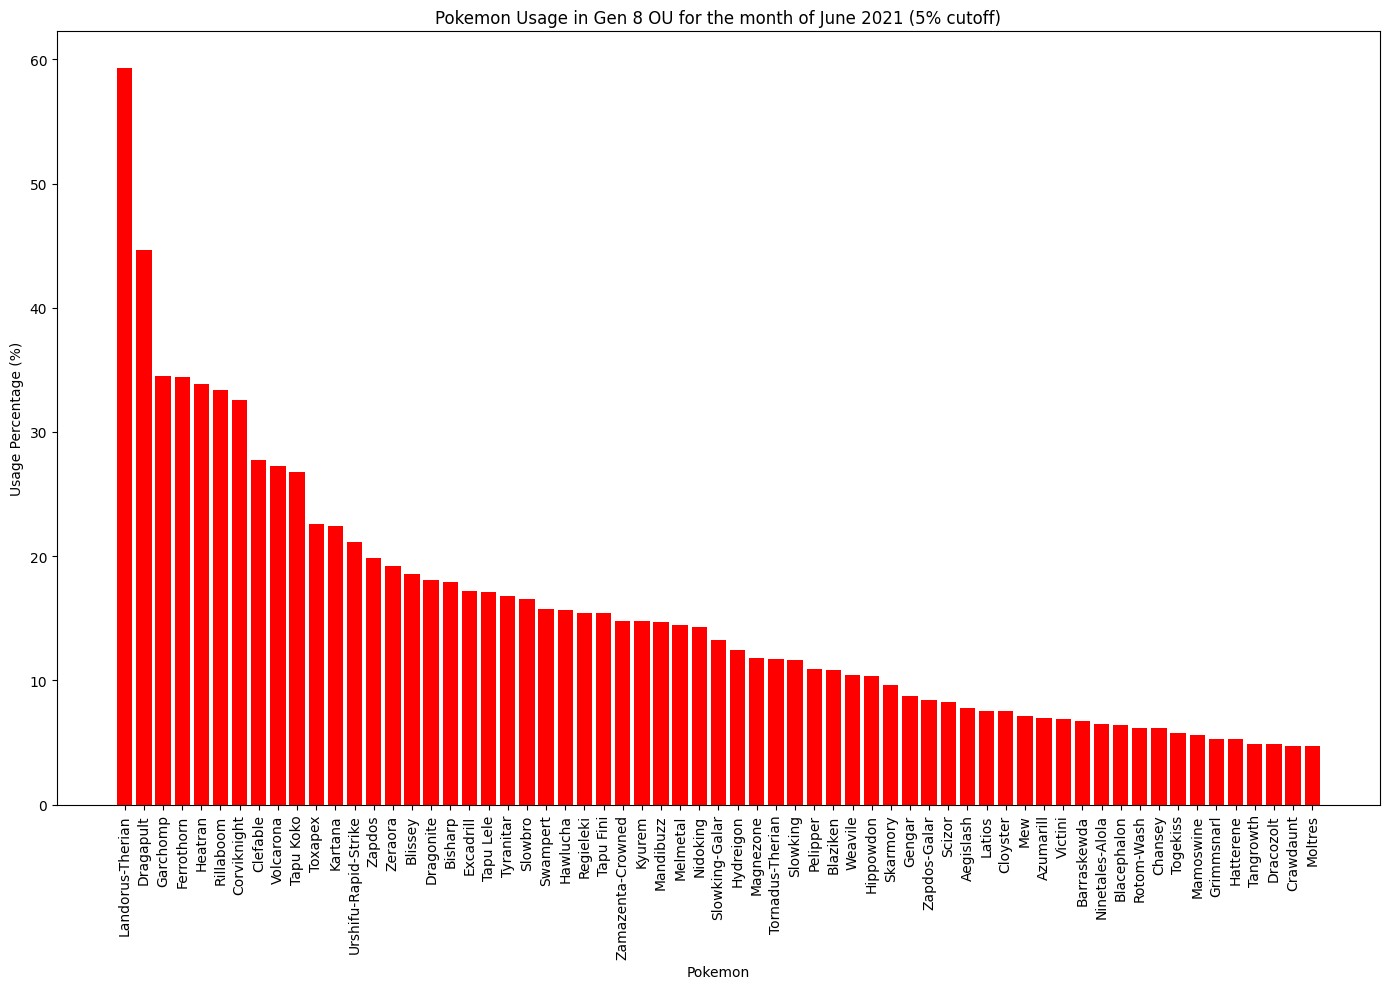

Number of Pokémon with over 10% usage: 40


In [5]:
usage_df = pd.read_csv(USAGE_CSV)

total_battles = usage_df["total_battles"].iloc[0]
usage_df["raw_percent"] = (usage_df["raw_usage"] / total_battles) * 100
filtered = usage_df[usage_df["raw_percent"] >= 4.52]
filtered = filtered.sort_values("raw_percent", ascending=False)

plt.figure(figsize=(14,10))
plt.bar(filtered["pokemon"], filtered["raw_percent"], color = "red")
plt.xticks(rotation=90)
plt.ylabel("Usage Percentage (%)")
plt.xlabel("Pokemon")
plt.title("Pokemon Usage in Gen 8 OU for the month of June 2021 (5% cutoff)")
plt.tight_layout()
plt.show()
over_10_count = (usage_df["raw_percent"] > 10.0).sum()
print("Number of Pokémon with over 10% usage:", over_10_count)


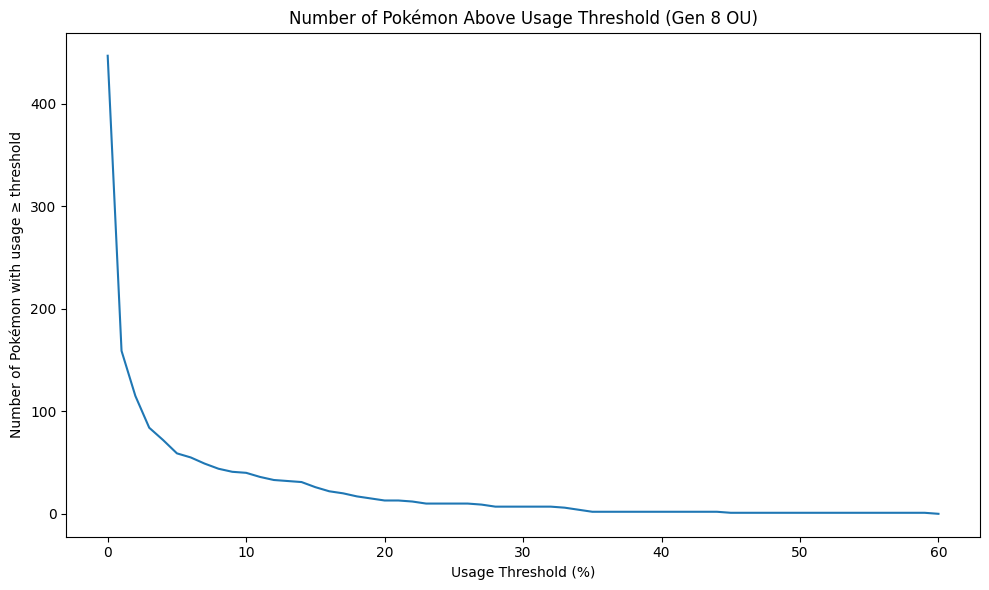

In [6]:
max_usage = usage_df["raw_percent"].max()
thresholds = np.arange(0, max_usage + 1, 1)
counts = [(usage_df["raw_percent"] >= t).sum() for t in thresholds]

plt.figure(figsize=(10,6))
plt.plot(thresholds, counts)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Number of Pokémon Above Usage Threshold (Gen 8 OU)")
plt.tight_layout()
plt.show()

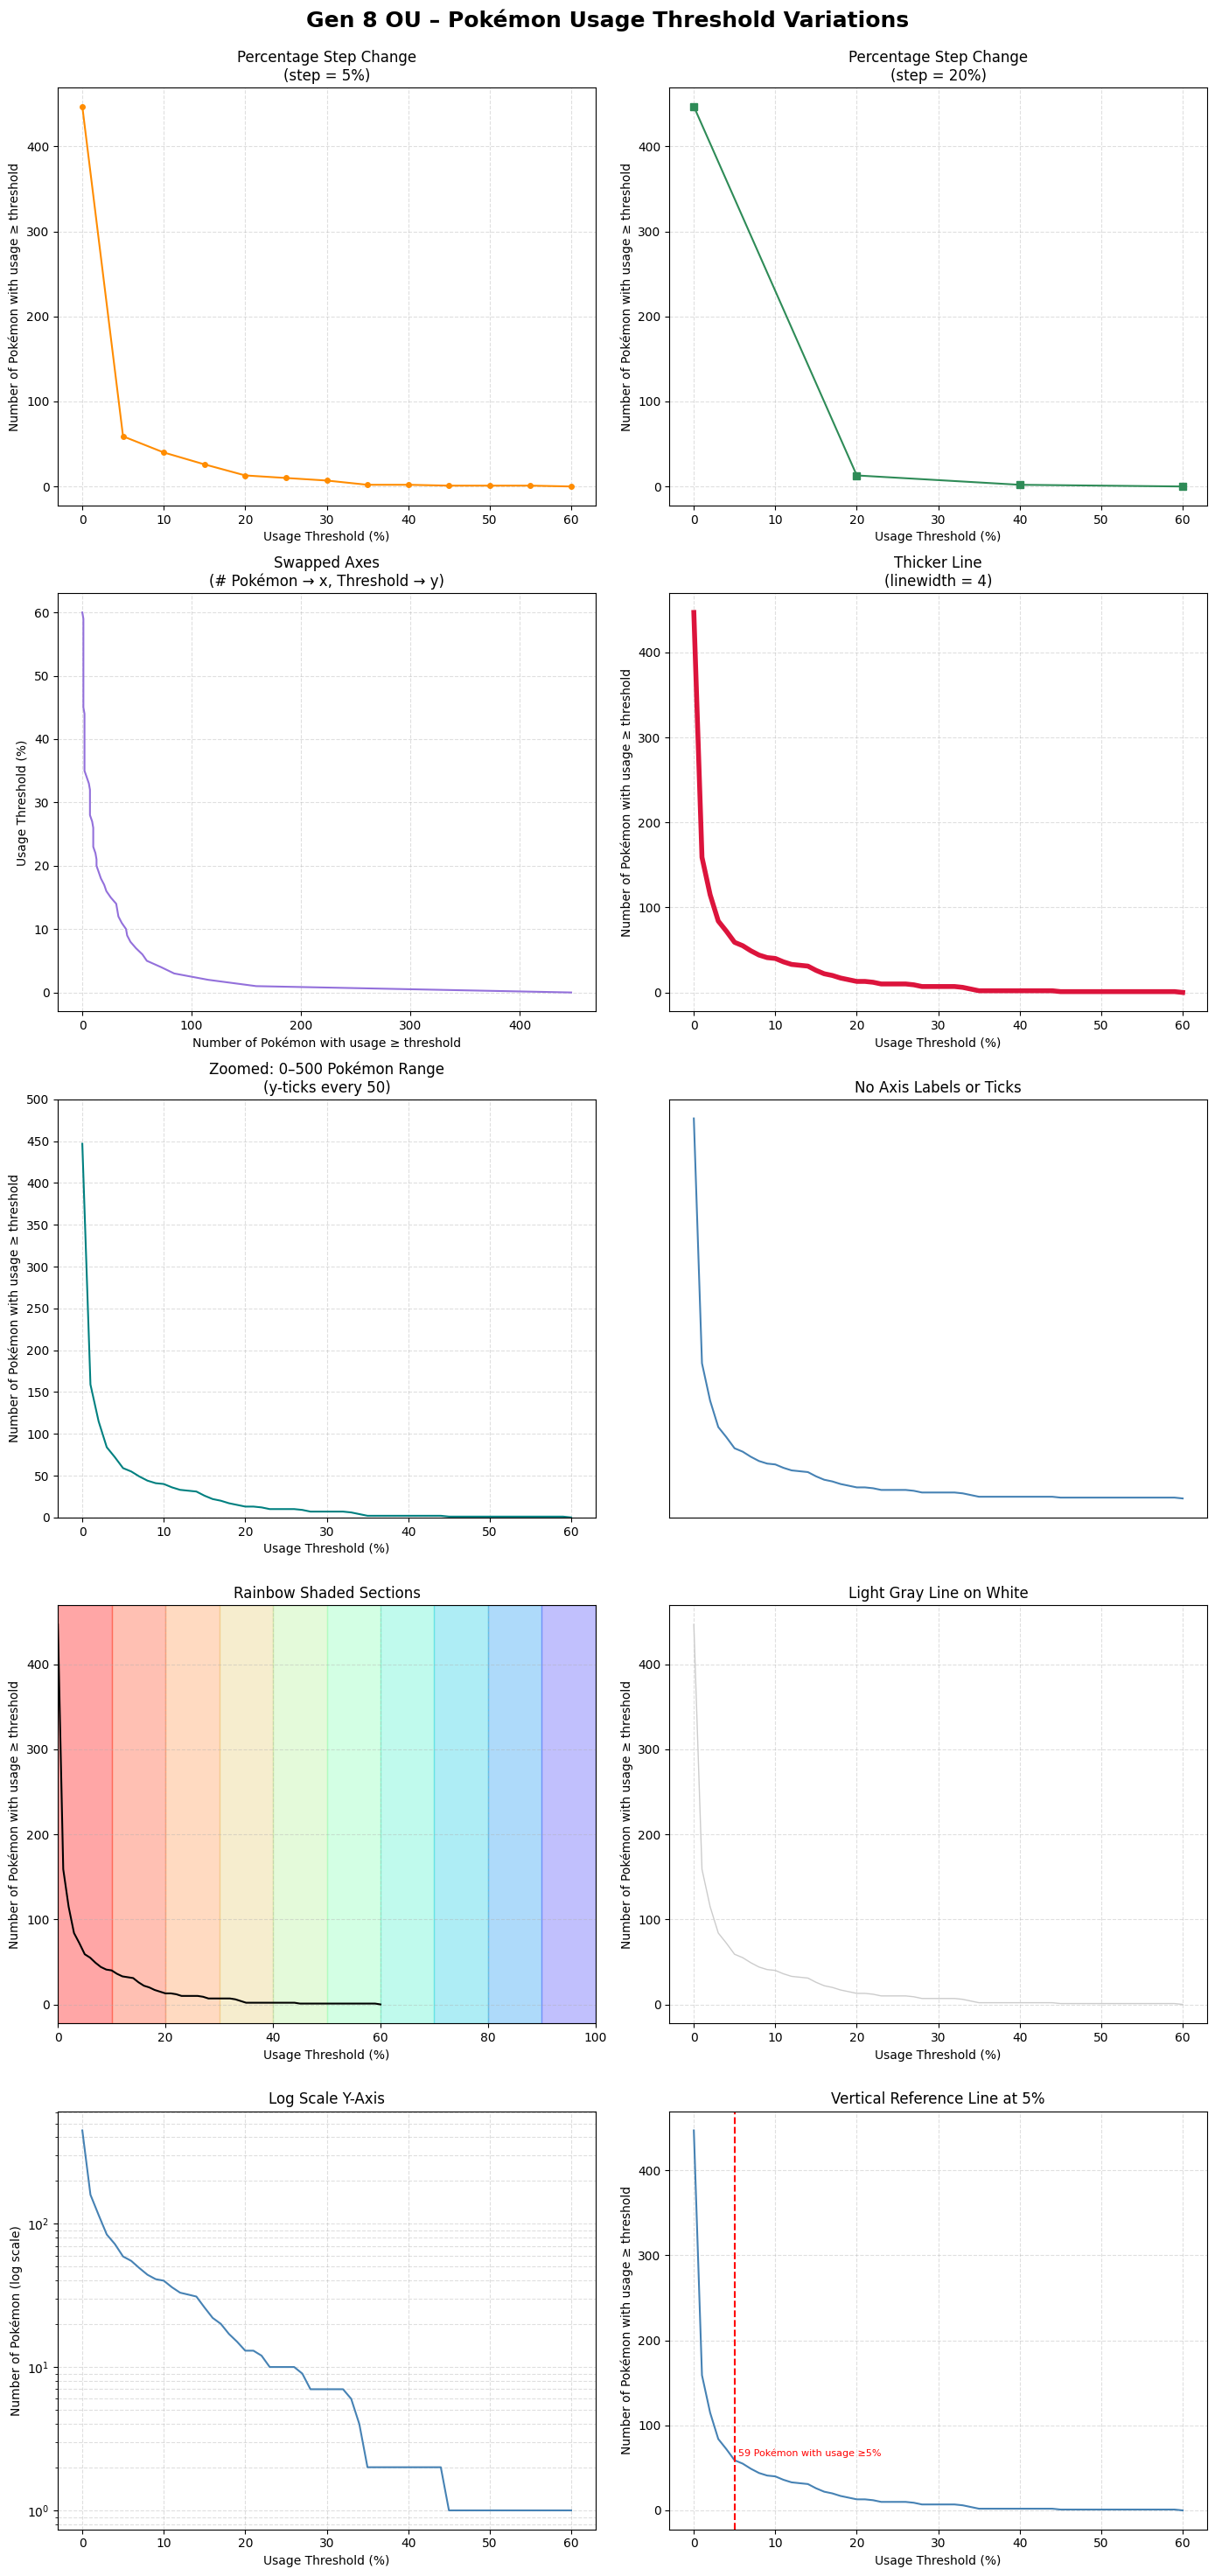

In [7]:
max_usage = usage_df["raw_percent"].max()

thresholds_1  = np.arange(0, max_usage + 1,  1)
thresholds_5  = np.arange(0, max_usage + 5,  5)
thresholds_20 = np.arange(0, max_usage + 20, 20)

counts_1  = [(usage_df["raw_percent"] >= t).sum() for t in thresholds_1]
counts_5  = [(usage_df["raw_percent"] >= t).sum() for t in thresholds_5]
counts_20 = [(usage_df["raw_percent"] >= t).sum() for t in thresholds_20]

zoom_thresh = [(t, c) for t, c in zip(thresholds_1, counts_1) if c <= 500]
zoom_t, zoom_c = zip(*zoom_thresh) if zoom_thresh else (thresholds_1, counts_1)

plt.figure(figsize=(14, 30))
plt.suptitle("Gen 8 OU – Pokémon Usage Threshold Variations", fontsize=18, fontweight="bold", y=0.98)

plt.subplot(5, 2, 1)
plt.plot(thresholds_5, counts_5, color="darkorange", marker="o", markersize=4)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Percentage Step Change\n(step = 5%)")
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(5, 2, 2)
plt.plot(thresholds_20, counts_20, color="seagreen", marker="s", markersize=6)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Percentage Step Change\n(step = 20%)")
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(5, 2, 3)
plt.plot(counts_1, thresholds_1, color="mediumpurple")
plt.xlabel("Number of Pokémon with usage ≥ threshold")
plt.ylabel("Usage Threshold (%)")
plt.title("Swapped Axes\n(# Pokémon → x, Threshold → y)")
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(5, 2, 4)
plt.plot(thresholds_1, counts_1, color="crimson", linewidth=4)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Thicker Line\n(linewidth = 4)")
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(5, 2, 5)
plt.plot(zoom_t, zoom_c, color="teal")
plt.ylim(0, 500)
plt.yticks(np.arange(0, 501, 50))
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Zoomed: 0–500 Pokémon Range\n(y-ticks every 50)")
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(5, 2, 6)
plt.plot(thresholds_1, counts_1, color="steelblue")
plt.xticks([])
plt.yticks([])
plt.xlabel("")
plt.ylabel("")
plt.title("No Axis Labels or Ticks")

plt.subplot(5, 2, 7)
rainbow = plt.get_cmap("rainbow")
section_size = 10
num_sections = 10
for i in range(num_sections):
    x_start = i * section_size
    x_end   = (i + 1) * section_size
    color   = rainbow(1 - i / num_sections)
    plt.axvspan(x_start, x_end, alpha=0.35, color=color)
plt.plot(thresholds_1, counts_1, color="black", linewidth=1.5)
plt.xlim(0, 100)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Rainbow Shaded Sections")
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(5, 2, 8)
plt.plot(thresholds_1, counts_1, color="#cccccc", linewidth=1)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Light Gray Line on White")
plt.grid(True, linestyle="--", alpha=0.4)

plt.subplot(5, 2, 9)
counts_log = [max(c, 1) for c in counts_1]
plt.plot(thresholds_1, counts_log, color="steelblue")
plt.yscale("log")
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon (log scale)")
plt.title("Log Scale Y-Axis")
plt.grid(True, linestyle="--", alpha=0.4, which="both")

plt.subplot(5, 2, 10)
ref_threshold = 5
ref_count     = int((usage_df["raw_percent"] >= ref_threshold).sum())
plt.plot(thresholds_1, counts_1, color="steelblue")
plt.axvline(x=ref_threshold, color="red", linestyle="--", linewidth=1.5)
plt.text(ref_threshold + 0.5, ref_count + 5, f"{ref_count} Pokémon with usage ≥{ref_threshold}%",
         color="red", fontsize=8)
plt.xlabel("Usage Threshold (%)")
plt.ylabel("Number of Pokémon with usage ≥ threshold")
plt.title("Vertical Reference Line at 5%")
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

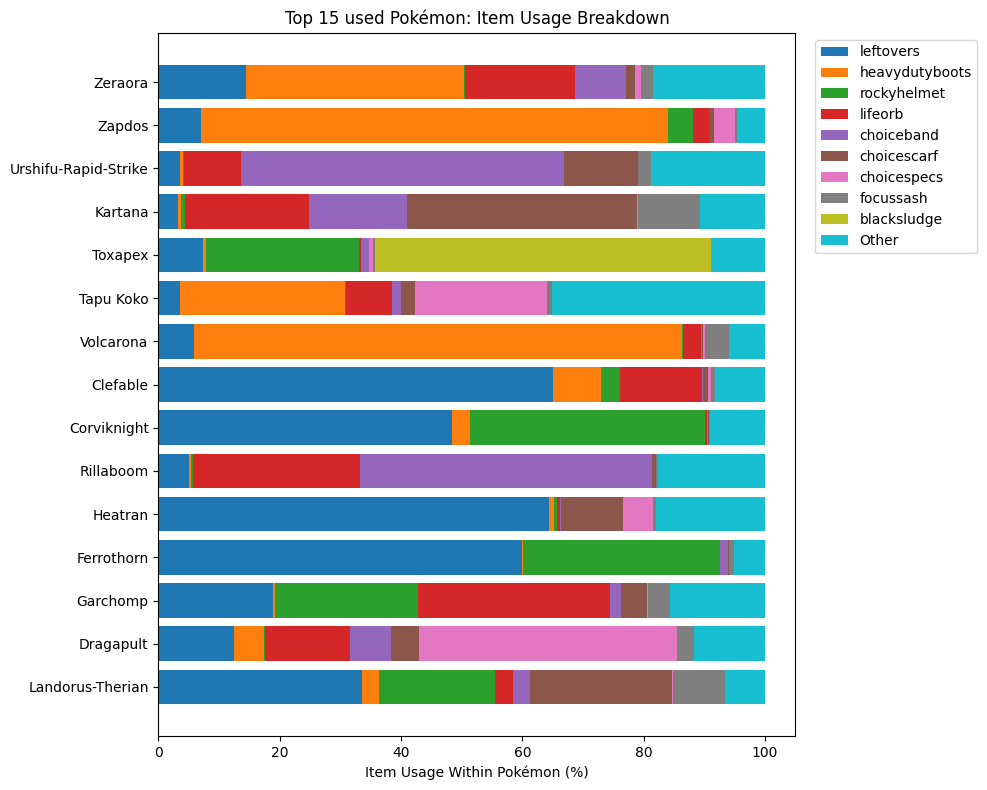

In [8]:

TOP_N_POKEMON = 15
TOP_N_ITEMS = 9
items_df = pd.read_csv(ITEMS_CSV)

top_mons = (
    usage_df.sort_values("raw_percent", ascending=False)
    .head(TOP_N_POKEMON)["pokemon"]
    .tolist()
)

items_sub = items_df[items_df["pokemon"].isin(top_mons)].copy()
items_sub = items_sub.set_index("pokemon")
items_sub = items_sub.apply(pd.to_numeric, errors="coerce").fillna(0)
items_sub = items_sub.reindex(top_mons)

top_items = items_sub.sum(axis=0).sort_values(ascending=False).head(TOP_N_ITEMS).index.tolist()

row_totals = items_sub.sum(axis=1).replace(0, 1)
pct = (items_sub.div(row_totals, axis=0) * 100)

pct_top = pct[top_items].copy()
pct_top["Other"] = 100 - pct_top.sum(axis=1)

plt.figure(figsize=(10, 8))
left = [0] * len(pct_top.index)

for col in pct_top.columns:
    plt.barh(pct_top.index, pct_top[col].values, left=left, label=col)
    left = [l + v for l, v in zip(left, pct_top[col].values)]

plt.xlabel("Item Usage Within Pokémon (%)")
plt.title(f"Top {TOP_N_POKEMON} used Pokémon: Item Usage Breakdown")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
